In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df['target'] = data.target

df.head()
df.describe()
df.info()
df['target'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

,count
target,
1,357
0,212


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

In [5]:
# =========================
# Logistic Regression
# =========================
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression
     (random_state=42,max_iter=1000))
])

In [6]:
# =========================
# Random Forest
# =========================
pipe_rf = Pipeline([
    ('classifier', RandomForestClassifier
     (random_state=42,n_estimators=100))
])

In [7]:
# =========================
# Train
# =========================
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

# =========================
# Predict
# =========================
y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

# =========================
# Probability
# =========================
y_pred_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_pred_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]

# =========================
# Evaluation
# =========================
print('Logistic Regression')
print('Accuracy: ', accuracy_score(y_test, y_pred_lr))
print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred_lr))
print('Classification Report: \n', classification_report(y_test, y_pred_lr))
print('ROC AUC Score: ', roc_auc_score(y_test, y_pred_proba_lr))
print('Precision Score: ', precision_score(y_test, y_pred_lr))
print('Recall Score: ', recall_score(y_test, y_pred_lr))
print('F1 Score: ', f1_score(y_test, y_pred_lr))
print("================================================================")
print('Random Forest')
print('Accuracy: ', accuracy_score(y_test, y_pred_rf))
print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred_rf))
print('Classification Report: \n', classification_report(y_test, y_pred_rf))
print('ROC AUC Score: ', roc_auc_score(y_test, y_pred_proba_rf))
print('Precision Score: ', precision_score(y_test, y_pred_rf))
print('Recall Score: ', recall_score(y_test, y_pred_rf))
print('F1 Score: ', f1_score(y_test, y_pred_rf))

Logistic Regression
Accuracy:  0.9824561403508771
Confusion Matrix: 
 [[41  1]
 [ 1 71]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

ROC AUC Score:  0.9953703703703703
Precision Score:  0.9861111111111112
Recall Score:  0.9861111111111112
F1 Score:  0.9861111111111112
Random Forest
Accuracy:  0.956140350877193
Confusion Matrix: 
 [[39  3]
 [ 2 70]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96 

In [8]:
# =========================
# Cross Validation（交叉驗證）
# =========================
from sklearn.model_selection import cross_val_score
scores=cross_val_score(pipe_lr,X_train,y_train,cv=5,scoring="roc_auc")
print(scores)
print('Mean ROC AUC:',scores.mean())

[0.99638803 1.         0.97213622 1.         0.99896801]
Mean ROC AUC: 0.993498452012384


In [14]:
# =========================
# GridSearchCV
# =========================
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_dapth':[2,3,5],
    'learning_rate':[0.01,0.1,0.3],
    'n_estimators':[50,100,200]
}
grid=GridSearchCV(XGBClassifier(
        random_state=42
    ),param_grid,cv=5,scoring="roc_auc",n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)
print(grid.best_score_)

{'learning_rate': 0.3, 'max_dapth': 2, 'n_estimators': 100}
0.9901960784313724


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:41:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "max_dapth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
# =========================
# XGBoost
# =========================
from xgboost import XGBClassifier
best_xgb = XGBClassifier(
    random_state=42,n_estimator=100
    ,max_depth=2,learning_rate=0.3)
best_xgb.fit(X_train, y_train)
y_pred_xgb = pipe_xgb.predict(X_test)
y_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
print('XGBoost')
print('Accuracy: ', accuracy_score(y_test, y_pred_xgb))
print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred_xgb))
print('Classification Report: \n', classification_report(y_test, y_pred_xgb))
print('ROC AUC Score: ', roc_auc_score(y_test, y_pred_proba_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:54:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
Accuracy:  0.956140350877193
Confusion Matrix: 
 [[38  4]
 [ 1 71]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

ROC AUC Score:  0.9907407407407407


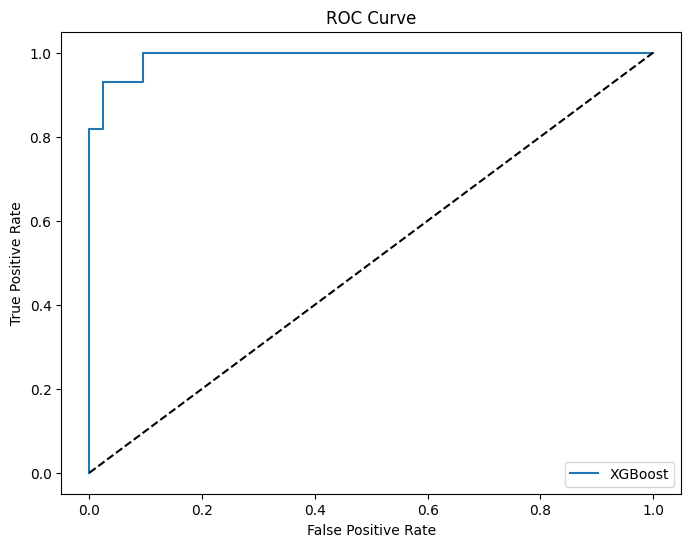

In [20]:
# =========================
# 畫 ROC Curve
# =========================
import matplotlib.pyplot as plt
fpr,tpr,thresholds=roc_curve(y_test,y_pred_proba_xgb)
auc=roc_auc_score(y_test,y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr,tpr,label="XGBoost")


plt.plot([0, 1], [0, 1], 'k--')   #亂猜模型

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()




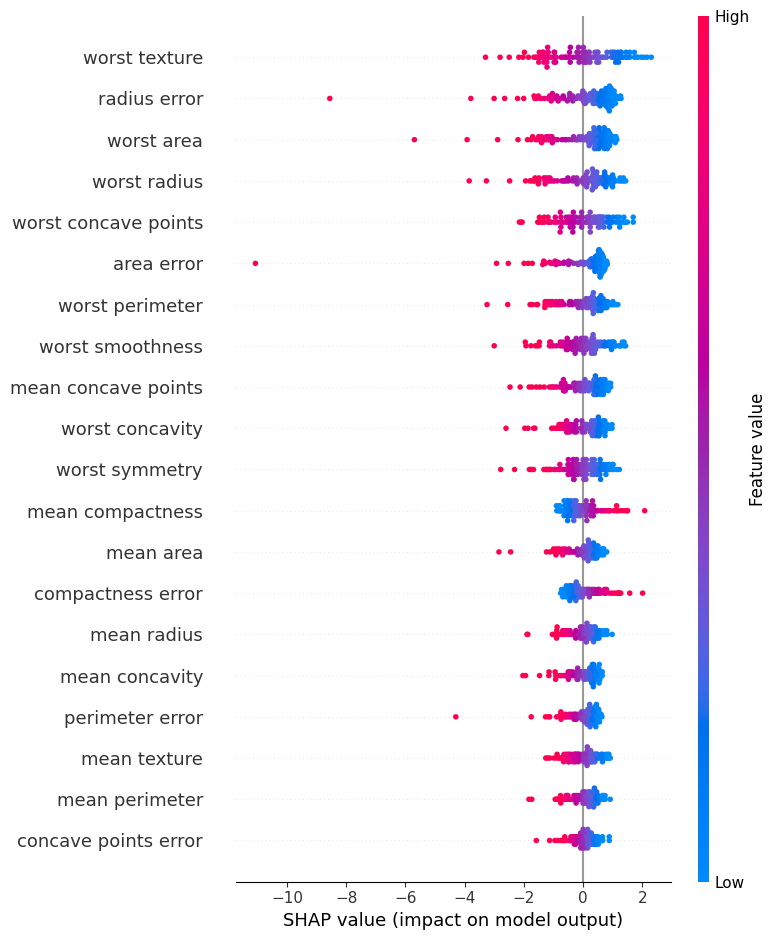

In [23]:
# =========================
# SHAP
# =========================
import shap
# scaling後資料
X_train_scaled = pipe_lr['scaler'].transform(X_train)
X_test_scaled = pipe_lr['scaler'].transform(X_test)

# explainer
explainer=shap.Explainer(pipe_lr.named_steps['classifier'],
            X_test_scaled)

# shap values
shap_values=explainer(X_test_scaled)

# =========================
# summary plot
# =========================
shap.summary_plot(shap_values, X_test, feature_names=X.columns )
#


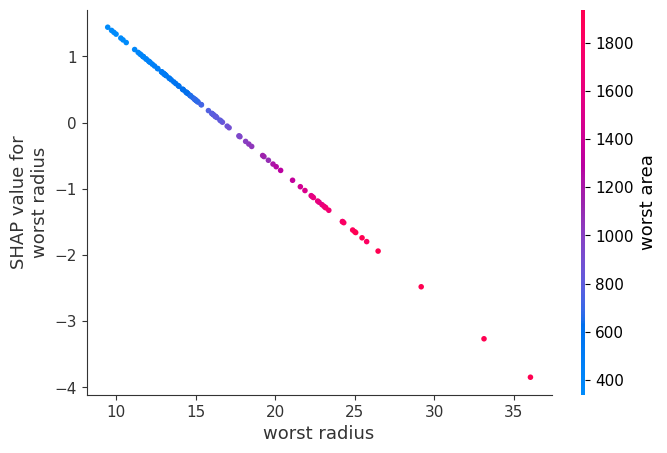

In [24]:
# =========================
# dependence plot
# =========================

shap.dependence_plot( 'worst radius', shap_values.values, X_test)

In [21]:
!pip freeze > requirements.txt